# 🏨 Hotel Cancellation Prediction: Logistic Regression Lab
## Can we predict which bookings will be cancelled before they happen?

---

### The Business Problem

Hotel cancellations are a massive headache for the hospitality industry.  
Consider a hotel with 200 rooms that is fully booked for a Saturday night:

- If **20% of bookings cancel** (a realistic figure), the hotel loses revenue on 40 rooms it could have re-sold.
- If the hotel **overbooks aggressively** and fewer people cancel than expected, it must walk guests to a competitor — destroying customer loyalty.
- You are a data scientist at a fast growing hotel brand and they need a better way to predict cancellations, they have a pretty good size
dataset and would like you to help. If the model works well you get a 10% bonus of all the recovered revenue!  

**A good cancellation-prediction model lets hotels:**
1. **Optimize overbooking** — sell the right number of extra rooms so the hotel fills up even after cancellations.
2.  **Improve staffing** — if 30% of tonight's bookings will cancel, fewer housekeepers and front-desk staff are needed.
3.  **Target at-risk bookings** — reach out proactively with incentives (free breakfast, discount upgrade) to guests who are likely to cancel.

### The Dataset

We are working with the **Hotel Booking Demand** dataset (~119 k real bookings from two Portuguese hotels).  
Our **target variable** is `is_canceled`: `1` if the booking was cancelled, `0` if the guest actually showed up.

### What You Will Build

| Model | Key idea |
|-------|----------|
| **Model 1** | Baseline pipeline — default solver (`lbfgs`), one-hot encoding + standard scaling |
| **Model 2** | Solver exploration — try using different solvers and see if the model improves |
| **Model 3** | Class-weighted logistic regression + cross-validation to handle imbalanced labels |



---
## 1 · Setup & Data Loading

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

sns.set_style('whitegrid')

In [25]:
df = pd.read_csv('hotels.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


---
## 2 · Exploratory Data Analysis

Before building any model we need to **understand our data**.  


In [26]:
# Print out summary stats and basic info on the dataset, what trends do you notice?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

There is a good mixture of qualitative and quantitative variables, and a majority of rows do not have any null variables.

In [27]:
# Calculate prevalence of the target value, how hard of problem is this going to be?

# Target class balance
counts = df['is_canceled'].value_counts()
print(counts)

# print out the percentage in the positive class, using a f string with 2 decimal places
positive_percentage = counts[1] / len(df) * 100
print(f"{positive_percentage:.2f}")

is_canceled
0    75166
1    44224
Name: count, dtype: int64
37.04


The 0s and 1s in is_canceled is not entirely balanced, but it is not severely imbalanced, so logistic regression will still work.

---
## 3 · Feature Engineering - Preparation

Before building any model we need to **understand our data**. 

In [28]:
# Check for missing data and drop features with too many missing values, there are some. 
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [29]:
# We will drop agent and company, then dropna to handle country and children
df = df.drop(columns=['agent', 'company'])
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 118898 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118898 non-null  str    
 1   is_canceled                     118898 non-null  int64  
 2   lead_time                       118898 non-null  int64  
 3   arrival_date_year               118898 non-null  int64  
 4   arrival_date_month              118898 non-null  str    
 5   arrival_date_week_number        118898 non-null  int64  
 6   arrival_date_day_of_month       118898 non-null  int64  
 7   stays_in_weekend_nights         118898 non-null  int64  
 8   stays_in_week_nights            118898 non-null  int64  
 9   adults                          118898 non-null  int64  
 10  children                        118898 non-null  float64
 11  babies                          118898 non-null  int64  
 12  meal                            

In [ ]:
# There are two other features that need to be dropped because they directly leak the target variable.
# Another way to say this is they represent leakage in the dataset.

# We are removing reservation_status_date as well since it is related to reservation_status
df_no_target = df.drop(columns=['is_canceled', 'reservation_status', 'reservation_status_date'])
df_no_target.info()

<class 'pandas.DataFrame'>
Index: 118898 entries, 0 to 119389
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118898 non-null  str    
 1   lead_time                       118898 non-null  int64  
 2   arrival_date_year               118898 non-null  int64  
 3   arrival_date_month              118898 non-null  str    
 4   arrival_date_week_number        118898 non-null  int64  
 5   arrival_date_day_of_month       118898 non-null  int64  
 6   stays_in_weekend_nights         118898 non-null  int64  
 7   stays_in_week_nights            118898 non-null  int64  
 8   adults                          118898 non-null  int64  
 9   children                        118898 non-null  float64
 10  babies                          118898 non-null  int64  
 11  meal                            118898 non-null  str    
 12  country                         

---
### Feature groups, see step 4 in the example (i think it goes 1,2,4 I deleted 3 and didn't change the numbering)

Create lists for the **numerical** and **categorical** so we can apply the right transformations to each group inside a `ColumnTransformer`.

> **Why scale numerics?** Logistic regression uses gradient descent internally.  
> Features on very different scales (e.g. `lead_time` 0–737 vs `adults` 0–4) slow convergence.  
> `StandardScaler` fixes this by converting each feature to mean=0, std=1.

> **Why one-hot encode categoricals?** Logistic regression can't handle strings.  
> One-hot encoding converts each category into its own binary (0/1) column.

Keep in mind that we want to use the pipeline package to handle this preprocessing so create lists of names of numeric and category then pass them into the pipeline, not necessarily creating different dataframes. 



In [31]:
# Prepare for the pipeline make sure to do so for both **numerical** and **categorical**. 
# Generate dataframe for the features and target variable, X and y.

CATEGORICAL = ['hotel', 'arrival_date_year', 'arrival_date_month', 'meal', 'country', 'market_segment',
               'distribution_channel', 'is_repeated_guest', 'reserved_room_type', 'assigned_room_type', 'deposit_type',
               'customer_type']
NUMERIC     = ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights',
               'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations',
               'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 
               'required_car_parking_spaces', 'total_of_special_requests']
TARGET      = 'is_canceled'

X = df_no_target[CATEGORICAL + NUMERIC]
y = df[TARGET]

In [32]:
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 95118 rows | Test: 23780 rows


---
## 4 · Model Building and Evaluation

Now we are going to build our **model pipeline** and use the transformers

---
Model 1 — Baseline Logistic Regression

Our first pipeline is intentionally **simple**.  
The goal is to establish a baseline score we can try to beat later.
Transformer categorical using one-hot encoding and numerical using the MinMaxscaler()

X_raw  →  ColumnTransformer  →  LogisticRegression(solver='lbfgs')
           (scale + encode)


**`lbfgs`** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is sklearn's default solver, like we talked about in class

In [33]:
# sklearn Pipeline
preprocessor_m1 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) # scale numerical cols
])

pipe_m1 = Pipeline(steps=[
    ('prep',  preprocessor_m1),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m1.fit(X_train, y_train)

/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

---
 Model 1 Evaluation: Now that the model is build lets evaluate the model using confusion matrix and ROC/AUC. Give the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:

| | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.

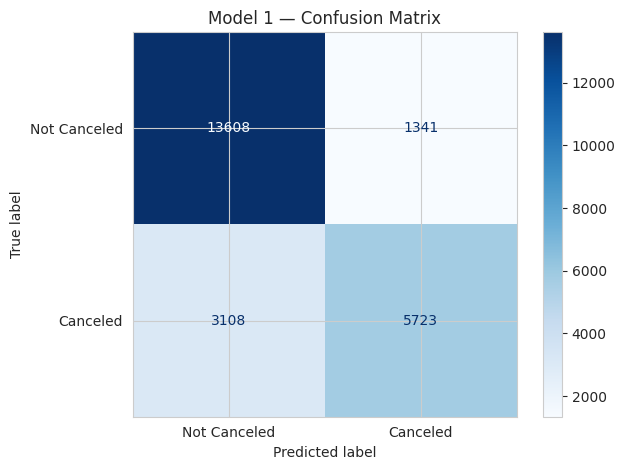

              precision    recall  f1-score   support

Not Canceled       0.81      0.91      0.86     14949
    Canceled       0.81      0.65      0.72      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.78      0.79     23780
weighted avg       0.81      0.81      0.81     23780



In [38]:
y_pred_m1 = pipe_m1.predict(X_test)
cm_m1 = confusion_matrix(y_test, y_pred_m1)
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Not Canceled', 'Canceled'])
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m1, target_names=['Not Canceled', 'Canceled']))

The model's overall accuracy is 81%, which is decent. Recall is 0.91 for Not Canceled compared to 0.65 for Canceled, meaning that the model performs better at identifying “Not Canceled” bookings than "Canceled" bookings. Precision is 0.81 for both, meaning predictions are generally reliable for both Not Canceled and Canceled.

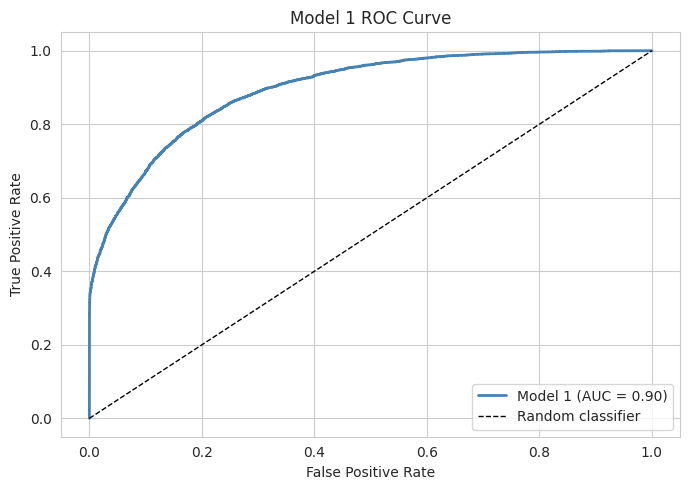

Model 1 ROC-AUC: 0.90


In [41]:
y_proba_m1 = pipe_m1.predict_proba(X_test)[:, 1]
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)
auc_m1 = roc_auc_score(y_test, y_proba_m1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1:.2f}")

ROC-AUC is 0.90, which means that the model has decent discriminatory ability between Not Canceled and Canceled bookings.

---
## 5 · Model 2 — Exploring Different Solvers 

- Adjust your model object in the pipeline then evaluate again using confusion matrix and ROC/AUC. Make sure to eval on the test set. You should create a model_2_pipe, use much of the same code but create a new pipeline for each model

Sklearn's `LogisticRegression` supports several **solvers** (optimisation algorithms) and  
**regularisation strategies** controlled by `l1_ratio` and `C`.

| Solver | Best for |
|--------|----------|
| `lbfgs` | Default; works well on most datasets (L2 regularisation) |
| `liblinear` | Smaller datasets; supports L1 via `l1_ratio=1` |
| `saga` | Large datasets; supports L1, L2, and ElasticNet |


Did the model improve based on the various solvers?



In [ ]:
# sklearn Pipeline 
preprocessor_m2 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) # scale numerical cols
])

# Solver: lbfgs
pipe_m2_lbfgs = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42, n_jobs=-1))
])
pipe_m2_lbfgs.fit(X_train, y_train)

# Solver: liblinear
pipe_m2_liblinear = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(solver='liblinear', max_iter=5000, random_state=42, n_jobs=-1))
])
pipe_m2_liblinear.fit(X_train, y_train)

# Solver: saga
pipe_m2_saga = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(solver='saga', max_iter=5000, random_state=42, n_jobs=-1))
])
pipe_m2_saga.fit(X_train, y_train)

/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

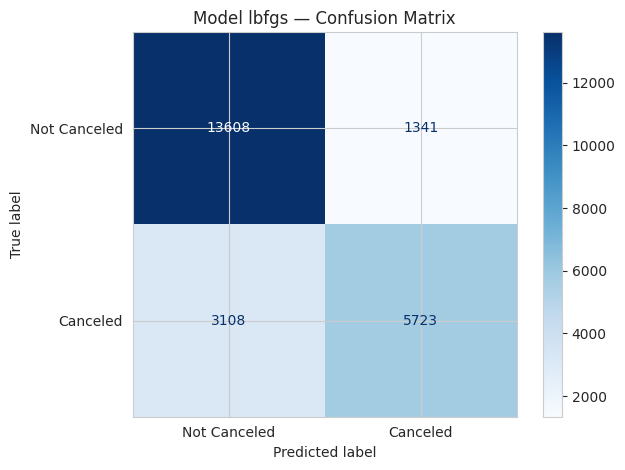

              precision    recall  f1-score   support

Not Canceled       0.81      0.91      0.86     14949
    Canceled       0.81      0.65      0.72      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.78      0.79     23780
weighted avg       0.81      0.81      0.81     23780



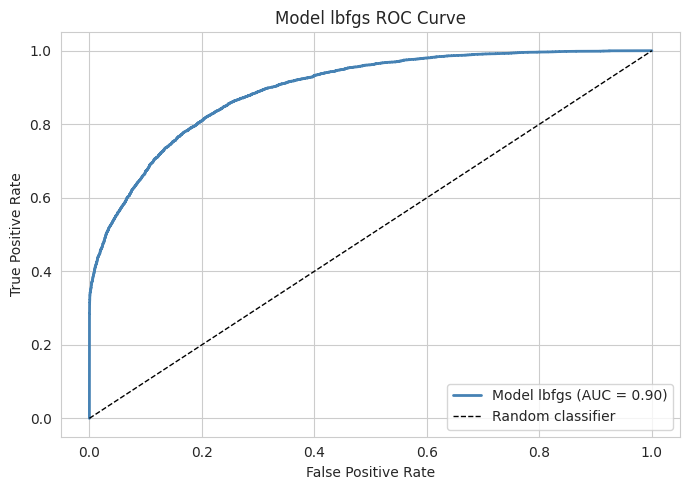

Model lbfgs ROC-AUC: 0.90


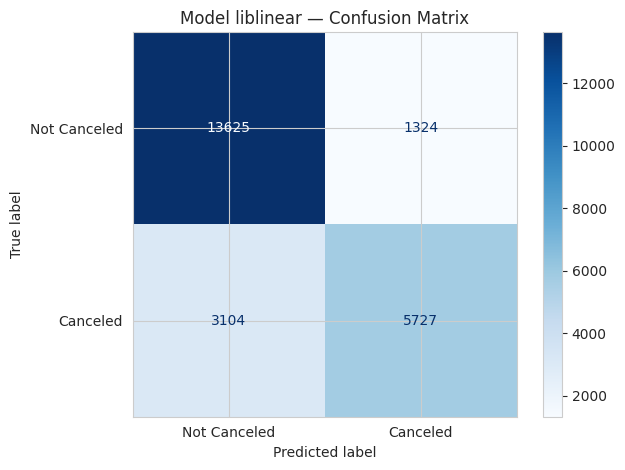

              precision    recall  f1-score   support

Not Canceled       0.81      0.91      0.86     14949
    Canceled       0.81      0.65      0.72      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.78      0.79     23780
weighted avg       0.81      0.81      0.81     23780



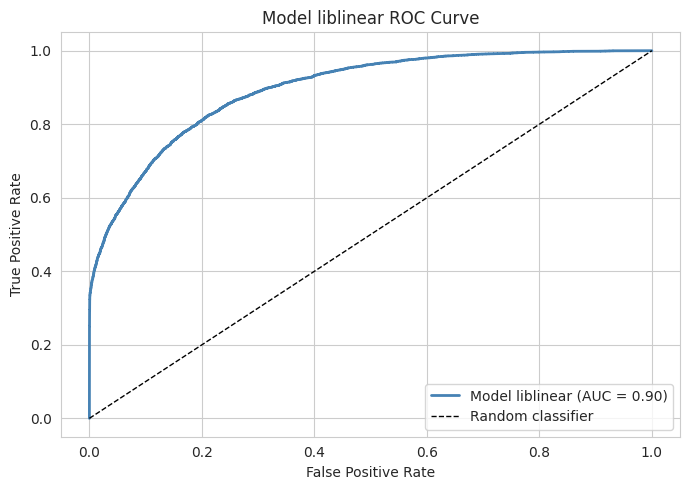

Model liblinear ROC-AUC: 0.90


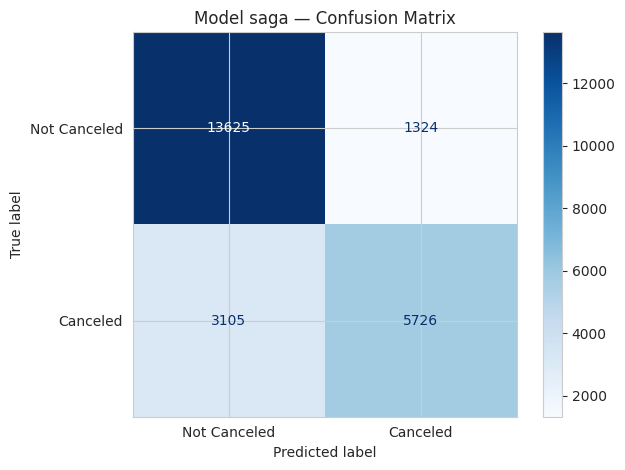

              precision    recall  f1-score   support

Not Canceled       0.81      0.91      0.86     14949
    Canceled       0.81      0.65      0.72      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.78      0.79     23780
weighted avg       0.81      0.81      0.81     23780



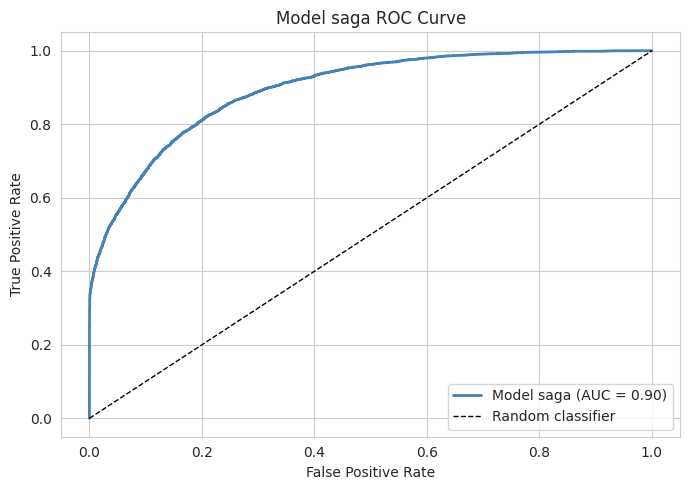

Model saga ROC-AUC: 0.90


In [46]:
models = {'lbfgs': pipe_m2_lbfgs,
    'liblinear': pipe_m2_liblinear,
    'saga': pipe_m2_saga}

for name, pipe in models.items():

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    disp_m = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Canceled', 'Canceled'])
    disp_m.plot(cmap='Blues')
    plt.title(f"Model {name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, y_pred, target_names=['Not Canceled', 'Canceled']))

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'Model {name} (AUC = {auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f"Model {name} ROC Curve")
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    print(f"Model {name} ROC-AUC: {auc:.2f}")

No, the model did not improve based on various solvers. This is because the logistic regression model is the same, and it is just using different solvers to optimize, so the predictions and performance results are similar.

---
## 6 · Model 3 — Balanced Class Weights + Cross-Validation

Build a final model (pipe_3) with a balanced class weight and use cross validation. As a reminder cv happens on the fit process not as part of the pipeline and we need to build our CV object, similar to the model object. . 

Use the example shown in class to see how to apply cross validation, balanced weight is a argument in the logreg function that you just need to apply as seen below. 

### The Class Imbalance Problem

Our dataset has ~63% non-cancellations and ~37% cancellations.  
A lazy model could achieve 63% accuracy by *always* predicting "Kept"!  
We saw that Models 1 and 2 sometimes struggled with **recall on the cancelled class**.

### Solution: `class_weight='balanced'`

Setting `class_weight='balanced'` tells sklearn to automatically weight the training samples  
so that the minority class (cancellations) gets more attention during training.

Specifically, each class gets weight = `n_samples / (n_classes × n_samples_in_class)`.

### Solution: Cross-Validation

Instead of a single train/test split (which can be lucky or unlucky),  
**k-fold cross-validation** trains and evaluates the model on `k` different splits  
and reports the average — giving a much more reliable estimate of real-world performance.

```
Fold 1: [train | train | train | train | VAL ]
Fold 2: [train | train | train | VAL  | train]
Fold 3: [train | train | VAL  | train | train]
...and so on
```

---

### Experiments

- Change the number of folds from `5` to `10` — does the mean AUC change much?
- Try removing `class_weight='balanced'` — what happens to recall on the cancelled class?

In [52]:
# sklearn Pipeline 
preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) # scale numerical cols
])

pipe_m3 = Pipeline(steps=[
    ('prep',  preprocessor_m3),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1, class_weight='balanced'))
])

In [ ]:
# 5-fold cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc  = cross_val_score(pipe_m3, X, y, cv=cv, scoring='roc_auc')

print("5-Fold Cross-Validation Results (Logistic Regression):")
print(f"  ROC-AUC : {cv_auc.mean():.2f}  ± {cv_auc.std():.2f}  | folds: {np.round(cv_auc, 2)}")

/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_

5-Fold Cross-Validation Results (Logistic Regression):
  ROC-AUC : 0.89  ± 0.00  | folds: [0.89 0.89 0.89 0.89 0.9 ]


/tmp/ipykernel_43146/2960390009.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,


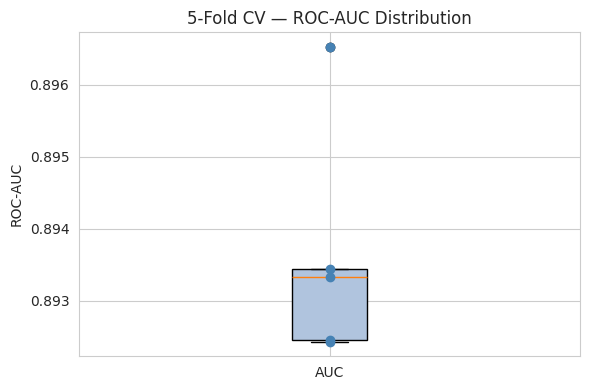

In [56]:
# Box-plot of fold AUCs (5 fold)
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.scatter([1]*5, cv_auc, color='steelblue', zorder=3)
ax.set_title('5-Fold CV — ROC-AUC Distribution')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

In [ ]:
# 10-fold cross-validation

cv = StratifiedKFold(n_splits=10 , shuffle=True, random_state=42)

cv_auc  = cross_val_score(pipe_m3, X, y, cv=cv, scoring='roc_auc')

print("10-Fold Cross-Validation Results (Logistic Regression):")
print(f"  ROC-AUC : {cv_auc.mean():.2f}  ± {cv_auc.std():.2f}  | folds: {np.round(cv_auc, 2)}")

/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_

10-Fold Cross-Validation Results (Logistic Regression):
  ROC-AUC : 0.89  ± 0.00  | folds: [0.9  0.89 0.89 0.89 0.89 0.9  0.89 0.9  0.89 0.9 ]


/tmp/ipykernel_43146/2582455366.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,


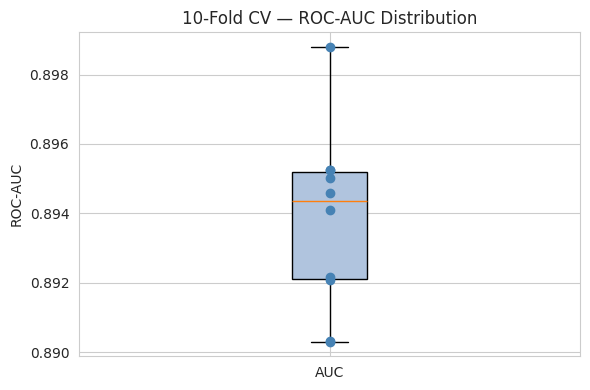

In [59]:
# Box-plot of fold AUCs (10 fold)
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.scatter([1]*10, cv_auc, color='steelblue', zorder=3)
ax.set_title('10-Fold CV — ROC-AUC Distribution')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


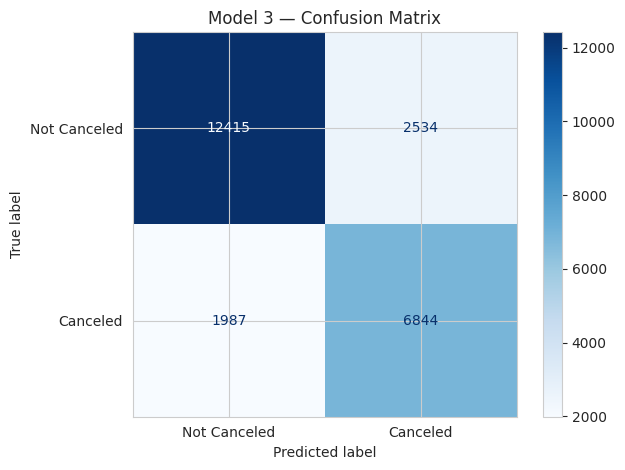

              precision    recall  f1-score   support

Not Canceled       0.86      0.83      0.85     14949
    Canceled       0.73      0.77      0.75      8831

    accuracy                           0.81     23780
   macro avg       0.80      0.80      0.80     23780
weighted avg       0.81      0.81      0.81     23780



In [62]:
pipe_m3.fit(X_train, y_train)

y_pred_m3 = pipe_m3.predict(X_test)
cm_m3 = confusion_matrix(y_test, y_pred_m3)
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['Not Canceled', 'Canceled'])
disp_m3.plot(cmap='Blues')
plt.title('Model 3 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m3, target_names=['Not Canceled', 'Canceled']))

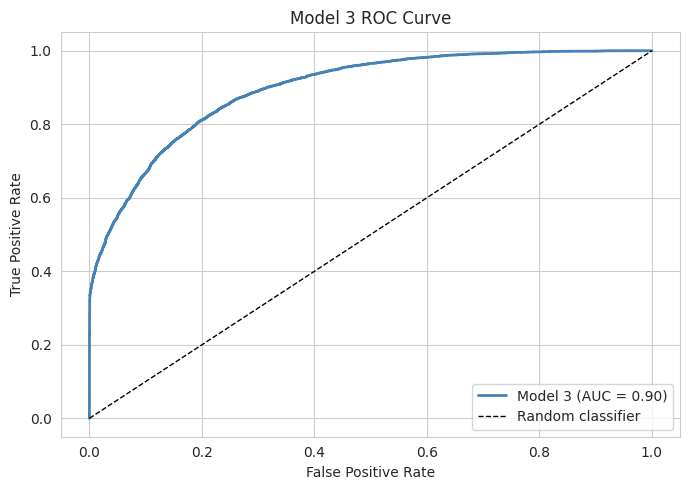

Model 3 ROC-AUC: 0.90


In [ ]:
y_proba_m3 = pipe_m3.predict_proba(X_test)[:, 1]
fpr_m3, tpr_m3, thresholds_m3 = roc_curve(y_test, y_proba_m3)
auc_m3 = roc_auc_score(y_test, y_proba_m3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m3, tpr_m3, lw=2, color='steelblue', label=f'Model 3 (AUC = {auc_m3:.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 ROC-AUC: {auc_m3:.2f}")

The AUC barely changed. This is because the dataset is large enough that different train-test splits produce similar results.

/workspaces/week_8/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


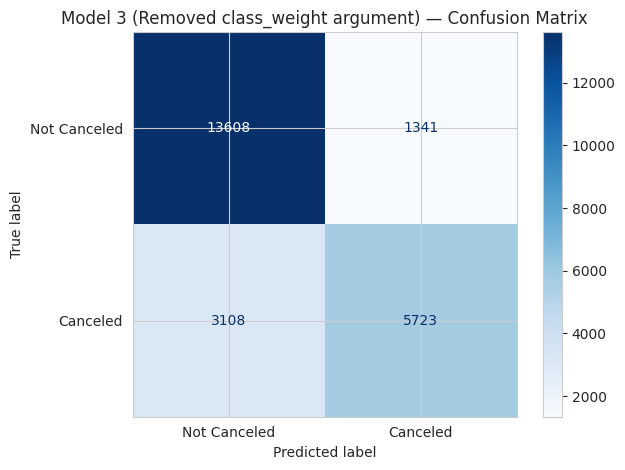

              precision    recall  f1-score   support

Not Canceled       0.81      0.91      0.86     14949
    Canceled       0.81      0.65      0.72      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.78      0.79     23780
weighted avg       0.81      0.81      0.81     23780



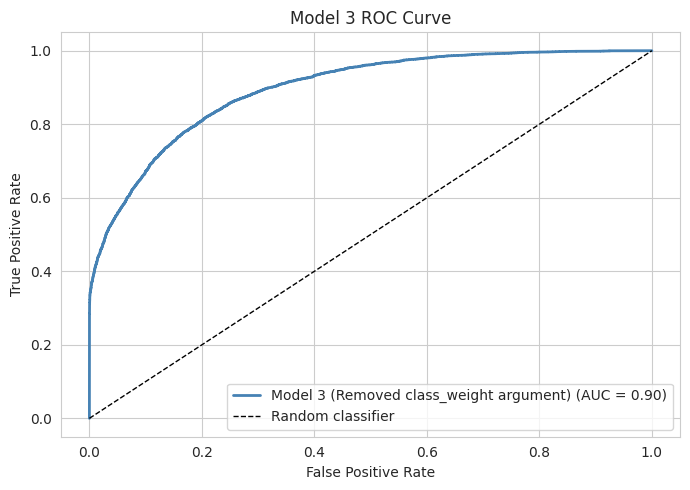

Model 3 (Removed class_weight argument) ROC-AUC: 0.90


In [70]:
# Try removing class_weight='balanced' (should return same results as before)

pipe_m3_rem = Pipeline(steps=[
    ('prep',  preprocessor_m3),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1))
])
pipe_m3_rem.fit(X_train, y_train)

y_pred_m3_rem = pipe_m3_rem.predict(X_test)
cm_m3_rem = confusion_matrix(y_test, y_pred_m3_rem)
disp_m3_rem = ConfusionMatrixDisplay(confusion_matrix=cm_m3_rem, display_labels=['Not Canceled', 'Canceled'])
disp_m3_rem.plot(cmap='Blues')
plt.title('Model 3 (Removed class_weight argument) — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m3_rem, target_names=['Not Canceled', 'Canceled']))

y_proba_m3_rem = pipe_m3_rem.predict_proba(X_test)[:, 1]
fpr_m3_rem, tpr_m3_rem, thresholds_m3_rem = roc_curve(y_test, y_proba_m3_rem)
auc_m3_rem = roc_auc_score(y_test, y_proba_m3_rem)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m3_rem, tpr_m3_rem, lw=2, color='steelblue', label=f'Model 3 (Removed class_weight argument) (AUC = {auc_m3:.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 (Removed class_weight argument) ROC-AUC: {auc_m3:.2f}")

WITH class_weight='balanced': Recall is 0.83 for Not Canceled compared to 0.77 for Canceled, meaning that the model performs better at identifying “Not Canceled” bookings than "Canceled" bookings. (more balanced than without)

WITHOUT class_weight='balanced': Recall is 0.91 for Not Canceled compared to 0.65 for Canceled, meaning that the model performs better at identifying “Not Canceled” bookings than "Canceled" bookings. (more IMbalanced than with)

This means that with class_weight='balanced', the model becomes more balanced and better at identifying cancellations.

---
## 07 · Summary & Reflection

### What We Learned

**Model Performance**
- Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)

### Challenge Extensions - extra 5 points for each

If you want to push further:

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.
2. **Engineer new features** — e.g. `total_nights = stays_in_weekend_nights + stays_in_week_nights`.
3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN
4. **Interpret coefficients** — given that the variables have been standardized create a horizontal bar chart showing
the rankings of the coeficients 

---

We select Model 3 with class_weight='balanced', which achieves an overall accuracy of 81%, with recall of 0.83 for Not Canceled and 0.77 for Canceled, and precision of 0.81 for both Not Canceled and Canceled. Using class_weight='balanced' increases the importance of the minority group (Canceled), ultimately allowing the model to better identify cancellations. We chose this model over the others because although the tradeoff is a decrease in correctly identifying non-cancellations, the model overall benefits from an increase in correctly identifying cancellations. This aligns more with the business goal since the goal is to better predict cancellations for the hotel.